In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import nltk
from nltk.corpus import stopwords
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from sklearn.metrics import confusion_matrix,classification_report

In [230]:
df = pd.read_csv("text.csv")

In [231]:
df.head()

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4


In [232]:
df.isnull().sum()

Unnamed: 0    0
text          0
label         0
dtype: int64

In [233]:
df.duplicated().sum()

np.int64(0)

In [234]:
df.shape

(416809, 3)

In [235]:
df.drop(columns = "Unnamed: 0",axis = 1,inplace = True)

In [236]:
df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [237]:
df[df["text"].str.contains("lol",case = False)]

,text,label
353,i feel bad for her but i a href http lolhunt,0
1828,i found working out of detroit specialized in ...,3
1957,i vow to be gasp nicer to everyone not just a ...,1
2337,i feel when i don t have my preworkout gym bod...,5
2544,im feeling happy with my progress because i di...,1
...,...,...
410997,i feel so amazed lol i think my father felt a ...,5
413877,i feel at peace when i get up before everybody...,1
415195,id feel terrible too not that you should feel ...,0
416123,i will have seven whole wonderful days off to ...,0


In [238]:
df.iloc[1828,0]

'i found working out of detroit specialized in christian literature lol im feeling a little grouchy tonight'

In [239]:
df['label'] = df['label'].replace(0,'Sadness')
df['label'] = df['label'].replace(1,'Joy')
df['label'] = df['label'].replace(2,'Love')
df['label'] = df['label'].replace(3,'Anger')
df['label'] = df['label'].replace(4,'Fear')
df['label'] = df['label'].replace(5,'Surprise')

In [240]:
df['label'].value_counts()

label
Joy         141067
Sadness     121187
Anger        57317
Fear         47712
Love         34554
Surprise     14972
Name: count, dtype: int64

/tmp/ipykernel_92297/3807124912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = count.index, y = count.values,palette='deep')


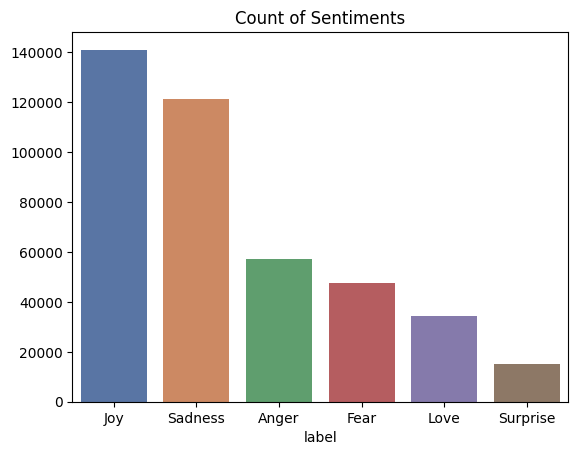

In [241]:
count = df['label'].value_counts()
sns.barplot(x = count.index, y = count.values,palette='deep')
plt.title("Count of Sentiments")
plt.show()

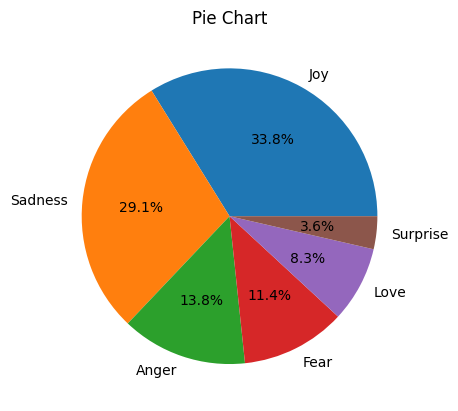

In [242]:
plt.pie(count.values,labels = count.index,autopct='%1.1f%%')
plt.title("Pie Chart")
plt.show()

# Unbalanced Dataset - Assigning Weights

In [243]:
joy = 1/0.338
sadness = 1/0.291
anger = 1/0.138
fear = 1/0.114
love = 1/0.083
surprise = 1/0.036

In [244]:
weights = {0: sadness,1: joy,2: love,3: anger,4: fear,5: surprise}

In [245]:
df['label'] = df['label'].replace('Sadness',0)
df['label'] = df['label'].replace('Joy',1)
df['label'] = df['label'].replace('Love',2)
df['label'] = df['label'].replace('Anger',3)
df['label'] = df['label'].replace('Fear',4)
df['label'] = df['label'].replace('Surprise',5)

/tmp/ipykernel_92297/402044218.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace('Surprise',5)


# Preprocessing

In [246]:
df['text'] = df['text'].str.replace(r'http\S+|www\S+','',regex = True) #Removes url's

In [247]:
df['text'] = df['text'].str.replace(r'[^\w\s]','',regex = True) #Removes special characters and punctuation

In [248]:
df['text'] = df['text'].str.replace(r'\s+',' ',regex = True) #Changes white space to a single white space

In [249]:
df['text'] = df['text'].str.replace(r'\d+','',regex = True) #Removes numbers

In [250]:
df['text'] = df['text'].str.lower()

In [251]:
df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [252]:
stop = set(stopwords.words('english'))
stop

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [253]:
df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [254]:
df['text'] = df['text'].apply(lambda x: ' '.join(i for i in x.split() if i not in stop)) #Removing stop words

In [255]:
df.head()

,text,label
0,feel really helpless heavy hearted,4
1,ive enjoyed able slouch relax unwind frankly n...,0
2,gave internship dmrg feeling distraught,4
3,dont know feel lost,0
4,kindergarten teacher thoroughly weary job take...,4


In [256]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42) #Split 80-20

In [257]:
X_train.shape

(333447,)

In [258]:
y_train.shape

(333447,)

In [259]:
X_test.shape

(83362,)

In [260]:
y_test.shape

(83362,)

In [261]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train) #Converting words into id's {this: 1, one: 2}
X_train_sequence = tokenizer.texts_to_sequences(X_train) #Making it only id's {1,2}
X_test_sequence = tokenizer.texts_to_sequences(X_test)

In [262]:
X_train_sequence

[[17, 27377, 69, 492, 4, 183, 17, 2, 34, 466, 10395, 1014],
 [273, 5, 725, 152, 2228, 1, 638, 81, 76, 1335, 588, 10, 551, 540, 859, 25],
 [1,
  44,
  718,
  393,
  29,
  36381,
  2,
  752,
  11947,
  1047,
  36382,
  183,
  111,
  4417,
  4995,
  3717,
  2795,
  2560,
  463,
  107,
  99,
  111,
  1935,
  227,
  7238],
 [2, 521, 5646, 1922, 124, 162, 45],
 [1, 3, 4, 568, 17, 16, 458],
 [1, 195, 12, 266, 50, 275, 311],
 [1, 59, 244, 2606, 644],
 [1, 428, 11364, 36383],
 [102, 1, 263],
 [12, 1841, 50, 1172, 12, 1, 243, 12636],
 [1, 7650, 1114, 987, 726, 8485, 181, 267, 62],
 [4034, 907, 111, 2655, 2560, 10396, 1, 3, 4, 505],
 [6,
  108,
  1,
  149,
  29,
  825,
  5553,
  5554,
  16,
  1345,
  1662,
  51,
  63,
  3688,
  5554,
  1761,
  2656],
 [36384, 5937, 38, 520, 19, 758, 1096],
 [3, 14, 1054, 73, 66, 364, 23, 76, 178, 1, 603, 10, 1208, 23, 1366],
 [4, 2, 258, 189, 1291],
 [1, 456, 236],
 [1, 3, 11, 97, 525, 740, 219, 268, 7065],
 [1, 1201, 1193, 438, 1307, 311, 2561, 22992, 38, 283, 8

In [263]:
maxlen = max(len(i) for i in X_train_sequence)
print("Maximum sequence length:",maxlen)

Maximum sequence length: 79


In [264]:
X_train_padded = pad_sequences(X_train_sequence,maxlen,padding = 'post') #Making every array same length by putting 0's
X_test_padded = pad_sequences(X_test_sequence,maxlen, padding = 'post')

In [265]:
X_train_padded

array([[   17, 27377,    69, ...,     0,     0,     0],
       [  273,     5,   725, ...,     0,     0,     0],
       [    1,    44,   718, ...,     0,     0,     0],
       ...,
       [    1,   592,     0, ...,     0,     0,     0],
       [    4,    15,   489, ...,     0,     0,     0],
       [    1,   149,  1768, ...,     0,     0,     0]], dtype=int32)

In [266]:
input_size = np.max(X_train_padded) + 1
print(input_size)

67782


In [267]:
model = Sequential([
    Embedding(input_size,100),
    BatchNormalization(),
    Bidirectional(LSTM(128,return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(6,activation='softmax')
])

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

In [268]:
history = model.fit(X_train_padded,y_train,epochs = 5,class_weight=weights,validation_data=[X_test_padded,y_test],batch_size = 128)

Epoch 1/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 137s 51ms/step - accuracy: 0.8581 - loss: 2.1014 - val_accuracy: 0.9395 - val_loss: 0.1222
Epoch 2/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 146s 56ms/step - accuracy: 0.9411 - loss: 0.6481 - val_accuracy: 0.9396 - val_loss: 0.1152
Epoch 3/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 149s 57ms/step - accuracy: 0.9430 - loss: 0.6097 - val_accuracy: 0.9407 - val_loss: 0.1176
Epoch 4/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 155s 59ms/step - accuracy: 0.9434 - loss: 0.5909 - val_accuracy: 0.9407 - val_loss: 0.1188
Epoch 5/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 155s 60ms/step - accuracy: 0.9442 - loss: 0.5836 - val_accuracy: 0.9399 - val_loss: 0.1223


In [269]:
model.evaluate(X_test_padded,y_test)

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 53s 20ms/step - accuracy: 0.9397 - loss: 0.1236


[0.12234596163034439, 0.9398646950721741]

In [270]:
y_pred = np.argmax(model.predict(X_test_padded),axis = 1)

1873/2606 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step


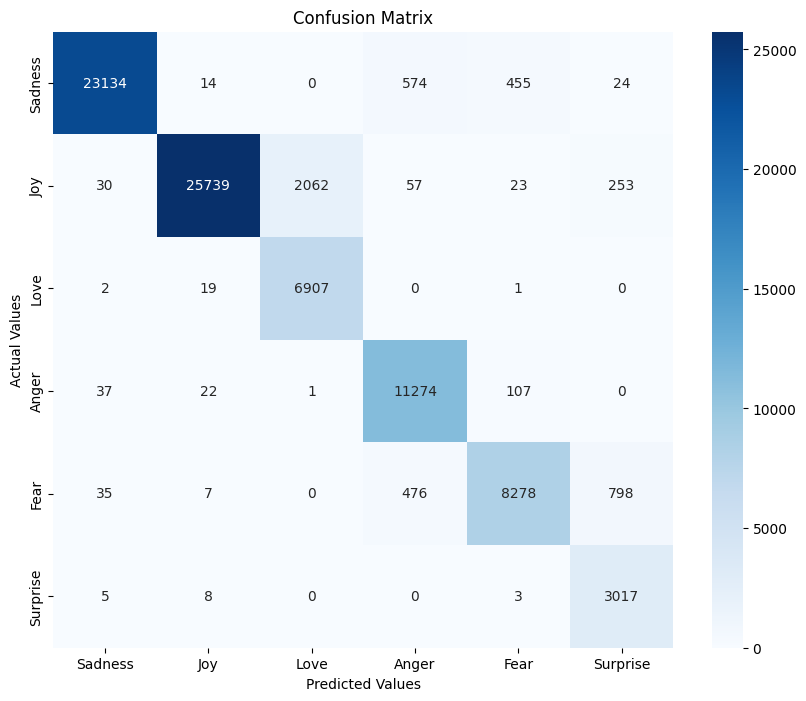

In [271]:
labels = {0:'Sadness',1:'Joy',2:'Love',3:'Anger',4:'Fear',5:'Surprise'}
labels = list(labels.values())
plt.figure(figsize = (10,8))
sns.heatmap(confusion_matrix(y_test,y_pred),cmap = 'Blues', annot = True,fmt = 'd',xticklabels = labels,
            yticklabels = labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [272]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     24201
           1       1.00      0.91      0.95     28164
           2       0.77      1.00      0.87      6929
           3       0.91      0.99      0.95     11441
           4       0.93      0.86      0.90      9594
           5       0.74      0.99      0.85      3033

    accuracy                           0.94     83362
   macro avg       0.89      0.95      0.91     83362
weighted avg       0.95      0.94      0.94     83362



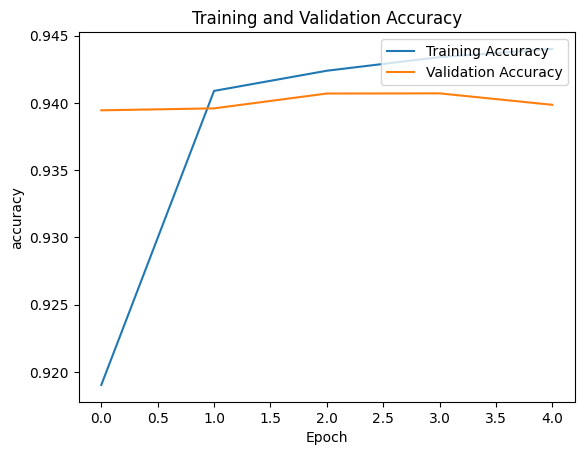

In [273]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='upper right')
plt.show()

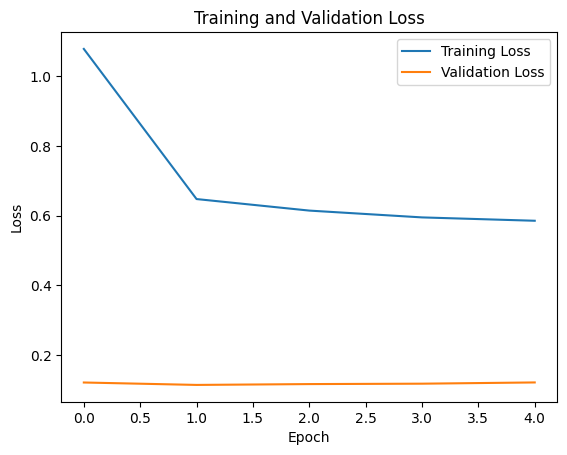

In [274]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training Loss', 'Validation Loss'], loc='upper right')
plt.show()

In [275]:
model.save("sentiment.h5")

In [276]:
def predict(text):
    text = re.sub(r'http\S+|www\S+', '', text)              
    text = re.sub(r'[^\w\s]', '', text)              
    text = re.sub(r'\s+', ' ', text)                 
    text = re.sub(r'\d+', '', text)                  
    text = text.lower()                                  
    text = [' '.join([word for word in text.split() if word not in stop])]
    sequence = tokenizer.texts_to_sequences(text)
    text = pad_sequences(sequence,maxlen,padding = 'post')
    predictions = model.predict(text)[0]
    plt.figure(figsize = (8,8))
    plt.bar(labels,predictions)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


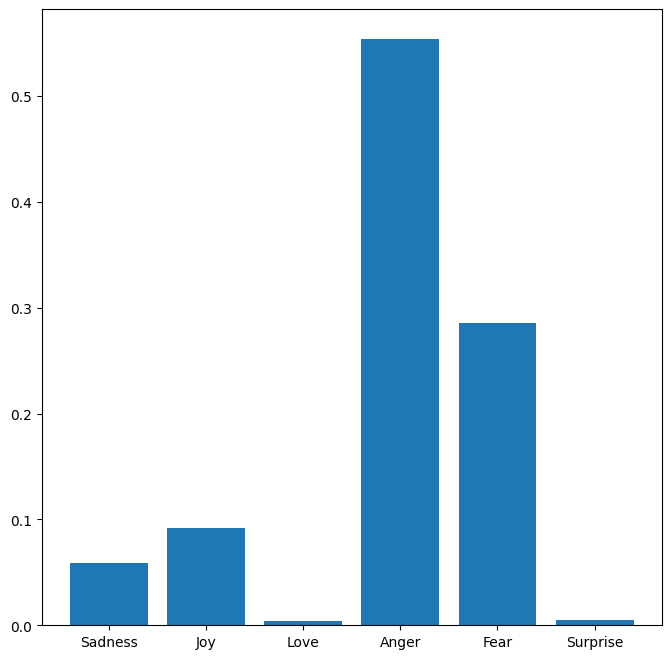

In [277]:
text = "Ahhhhhhhhhhhh, I wanna kill myself."
predict(text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


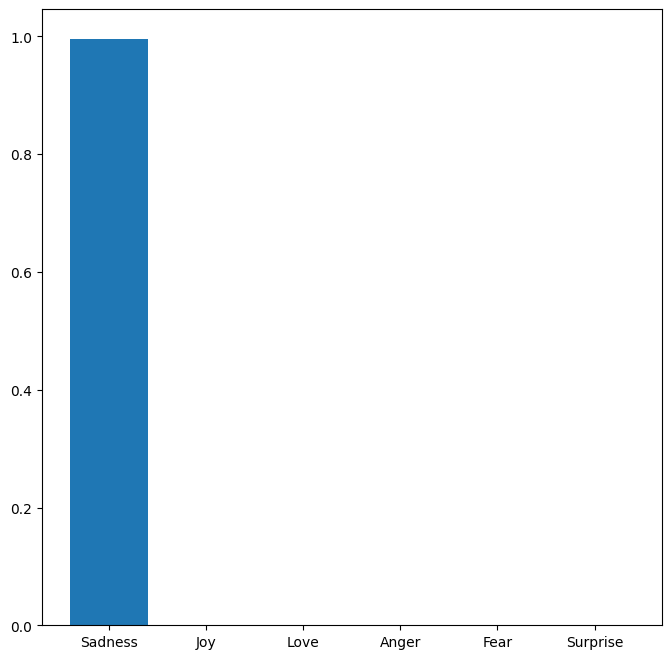

In [278]:
text = "I am very sad"
predict(text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


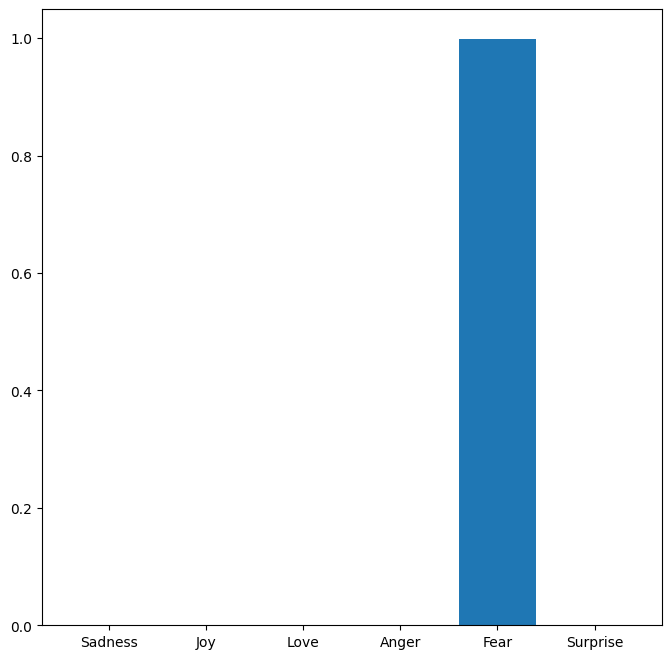

In [279]:
text = "I think, i am afraid."
predict(text)